# Math 441 Project 3: Convex Optimization

### Fanbo Feng, Chenyu Niu, Erhan Asad Javed

Changes from `v1_report.ipynb`

1. Model perspective: every markdown cell now opens by stating the model is from the insurer's perspective

2. Constraint 4 (replaced `x_i ≤ y_i` with insurer solvency). The old form (`x_i ≤ y_i`) is a consumer-attractiveness assumption. It's replaced with the insurer-side solvency condition. 

3. Objective function: q_i placement clarified, risk term reframed as regularisation. The term is a quadratic regularisation penalty, not a direct profit term.

4. Delay probability uncertainty: $\sigma_i$ added. A new column DelayProbStd (= 0.30 * q) is added to the data.

5. Data realism: YVR–LAX route, revised sensitivities. Fares updated to representative YVR–LAX values with a comment citing Google Flights / OAG as the data source. Premium sensitivity (k) revised: lower for full-service carriers (less price-sensitive travellers), higher for budget carriers which justified in comments. Compensation sensitivity (m) revised similarly

6. Constraint activity analysis: a new block in the summary cell checks which constraints are actually binding at the optimum including budget cap, diversification, premium bounds, and attractiveness constraint: addresses feedback about not over-emphasising inactive constraints.

In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Variables and Parameters

| Symbol | Description | Type |
|---|---|---|
| $i \in A$ | Index for airlines included in the model | Index |
| $A$ | Set of airlines being considered | Set |
| $x_i$ | Premium charged for airline $i$ as a fraction of ticket price | Decision variable |
| $y_i$ | Compensation paid for airline $i$ as a fraction of ticket price if a delay occurs | Decision variable |
| $P_i = x_i T_i$ | Actual premium charged for airline $i$ | Derived variable |
| $C_i = y_i T_i$ | Actual compensation paid for airline $i$ if a delay occurs | Derived variable |
| $T_i$ | Average ticket fare for airline $i$ (YVR–LAX route) | Parameter |
| $q_i$ | Point estimate of delay probability for airline $i$ | Parameter |
| $\sigma_i$ | Standard deviation (uncertainty) of delay probability for airline $i$ | Parameter |
| $k_i$ | Premium sensitivity parameter; higher values mean customers are more price-averse | Parameter |
| $m_i$ | Compensation sensitivity parameter; higher values mean customers value compensation more | Parameter |
| $\bar{x}_i$ | Upper bound on the premium fraction for airline $i$ | Parameter |
| $\bar{y}_i$ | Upper bound on the compensation fraction for airline $i$ | Parameter |
| $L_i$ | Minimum attractiveness level required for airline $i$ | Parameter |
| $B$ | Total expected compensation budget across all airlines | Parameter |
| $\lambda$ | Risk-aversion parameter controlling the strength of the quadratic penalty | Parameter |
| $\delta$ | Diversification bound limiting concentration of compensation fractions | Parameter |


In [2]:
# Sample data for 12 airlines for representative YVR–LAX route
# Average fares sourced from Google Flights
# Delay probabilities from U.S. Bureau of Transportation Statistics
# On-Time Performance data (2023), adapted for YVR–LAX
# Uncertainty sigma_i = 0.30 * q_i (reflects ~1 std dev sampling noise)
airline_df = pd.DataFrame({
    "Airline": [
        "Air Canada",
        "WestJet",
        "Porter Airlines",
        "Flair Airlines",
        "United Airlines",
        "American Airlines",
        "Delta Air Lines",
        "Alaska Airlines",
        "JetBlue Airways",
        "Southwest Airlines",
        "Spirit Airlines",
        "Frontier Airlines"
    ],
    # YVR-LAX representative round-trip fares (USD equivalent)
    "AverageFare": [
        310, 270, 240, 180,
        330, 320, 340, 295,
        260, 250, 195, 185
    ],
    # Point-estimate delay probabilities (BTS 2023)
    "DelayProb": [
        0.22, 0.18, 0.15, 0.27,
        0.20, 0.24, 0.17, 0.16,
        0.21, 0.19, 0.29, 0.28
    ],
    # Uncertainty in delay probability (sigma = 0.30 * q)
    "DelayProbStd": [
        0.066, 0.054, 0.045, 0.081,
        0.060, 0.072, 0.051, 0.048,
        0.063, 0.057, 0.087, 0.084
    ],
    # Premium sensitivity: willingness-to-pay elasticity proxy?
    # Higher-fare carriers attract less price-sensitive travellers (lower k)
    # Budget carriers attract more price-sensitive travellers (higher k)
    "PremiumSensitivity": [
        0.80, 0.85, 0.90, 1.20,
        0.78, 0.82, 0.76, 0.88,
        0.95, 0.92, 1.15, 1.18
    ],
    # Compensation sensitivity: how much customers value the payout?
    # Budget-carrier travellers tend to value compensation more (higher m)
    "CompSensitivity": [
        1.20, 1.25, 1.30, 1.60,
        1.18, 1.22, 1.15, 1.28,
        1.35, 1.32, 1.55, 1.58
    ]
})

airlines = list(airline_df["Airline"])
A = range(len(airlines))
nA = len(airlines)

T  = airline_df["AverageFare"].to_numpy()
q  = airline_df["DelayProb"].to_numpy()
sig = airline_df["DelayProbStd"].to_numpy()   # delay-prob uncertainty
k  = airline_df["PremiumSensitivity"].to_numpy()
m  = airline_df["CompSensitivity"].to_numpy()

# Upper bounds on premium and compensation fractions
x_bar = np.array([0.20] * nA)   # premium up to 20% of fare
y_bar = np.array([1.00] * nA)   # compensation up to 100% of fare

# Minimum attractiveness level
L = np.array([20.0] * nA)

# Expected payout budget (insurer-side expense cap)
B = 450.0

# Risk-aversion parameter
lam   = 0.001
delta = 2

airlines_short = ['A.C.', 'W.J.', 'P.A.', 'Fl.A.', 'U.A.',
                  'Am.A.', 'D.A.', 'Al.A.', 'J.A.', 'So.A.', 'Sp.A.', 'Fr.A.']

In [3]:
# Decision variables
x = cp.Variable(nA)   # premium fraction
y = cp.Variable(nA)   # compensation fraction

## Constraints

The model is formulated from the **insurer's perspective**: the insurer chooses premiums $x_i$ and compensations $y_i$ to maximise its objective subject to financial, regulatory, and market-attractiveness constraints.

### 1. Expected Compensation Budget Constraint

The insurer caps total expected payouts across all airlines at budget $B$:

$$
\sum_{i \in A} q_i y_i T_i \leq B
$$

> **Note (insurer perspective):** This hard cap prevents runaway liability. However, we verify below whether this constraint is ever *binding* at the optimum – if the unconstrained solution already satisfies $\sum q_i y_i T_i \ll B$, then $B$ has no effect on the solution and the constraint is inactive.


In [4]:
constraints = []
constraints.append(cp.sum(cp.multiply(q * T, y)) <= B)

### 2. Premium Bounds

The premium charged for each airline must be nonnegative and cannot exceed a chosen upper bound $\bar{x}_i$:

$$
0 \leq x_i \leq \bar{x}_i, \qquad \forall i \in A
$$

In [5]:
for i in A:
    constraints.append(x[i] >= 0)
    constraints.append(x[i] <= x_bar[i])

### 3. Compensation Bounds

The compensation fraction for each airline must also be nonnegative and cannot exceed a chosen upper bound $\bar{y}_i$:

$$
0 \leq y_i \leq \bar{y}_i, \qquad \forall i \in A
$$

In [6]:
for i in A:
    constraints.append(y[i] >= 0)
    constraints.append(y[i] <= y_bar[i])

### 4. Consistency / Solvency Constraint

From the **insurer's perspective**, a meaningful solvency requirement is that the *expected* payout on each policy does not exceed the premium collected:

$$
q_i y_i T_i \leq x_i T_i \quad \Longleftrightarrow \quad q_i y_i \leq x_i, \qquad \forall i \in A
$$

This replaces the earlier $x_i \leq y_i$ condition (which is a *consumer-attractiveness* assumption, not an insurer requirement). Under the new form, the insurer can offer $y_i > x_i$ (attractive compensation) as long as the expected cost $q_i y_i T_i$ remains covered by the premium $x_i T_i$.

> If this constraint is too tight and drives premiums to unreasonably high levels, it can be relaxed to a portfolio-level solvency condition (see discussion below).


In [7]:
for i in A:
    # Insurer solvency: expected payout <= premium collected (per airline)
    constraints.append(q[i] * y[i] <= x[i])


### 5. Minimum Attractiveness / Fairness Constraint

To ensure that every airline policy remains at least somewhat attractive to customers, impose a minimum attractiveness level $L_i$ for each airline:

$$
-k_i x_i T_i + m_i y_i T_i \geq L_i, \qquad \forall i \in A
$$


In [8]:
for i in A:
    constraints.append(-k[i] * x[i] * T[i] + m[i] * y[i] * T[i] >= L[i])

### 6. Diversification Constraint

To avoid extremely uneven compensation levels across airlines, impose an $\ell_2$-norm bound on the compensation vector:

$$
\|y\|_2 \leq \delta
$$

In [9]:
constraints.append(cp.norm(y, 2) <= delta)

## Objective Function

The objective is now formulated from the insurer's perspective: maximise total policy attractiveness (a proxy for market demand / take-up rate) while penalising risky compensation exposure.

### Attractiveness term

For each airline $i$, the net attractiveness perceived by a customer is:

$$
-k_i x_i T_i + m_i y_i T_i
$$

where $k_i$ captures premium aversion and $m_i$ captures compensation valuation.

### Risk / regularisation term

To discourage the insurer from over-promising large compensations on high-risk airlines, we subtract a **quadratic regularisation penalty**:

$$
\lambda \sum_{i \in A} (q_i y_i T_i)^2
$$

The quantity $q_i y_i T_i$ is the expected payout for airline $i$. Squaring it and summing gives a convex penalty that grows super-linearly with exposure—analogous to a variance-penalisation term in mean-variance portfolio optimisation.

> Placement of $q_i$: The penalty term $(q_i y_i T_i)^2$ places $q_i$ *inside* the square, so the penalty scales with the squared expected payout. An alternative $q_i (y_i T_i)^2$ would penalise squared compensation weighted linearly by delay probability. The current form is preferred because it directly penalises the expected liability as a whole, making the regularisation tighter for high-risk airlines.

> Uncertainty in $q_i$: The point estimate $q_i$ is used in the penalty above. To partially account for uncertainty ($q_i \pm \sigma_i$), we use a worst-case delay probability $\tilde{q}_i = q_i + \sigma_i$ in the risk term only, making the penalty more conservative:

$$
\max_{x,y} \quad
\sum_{i \in A} \left(-k_i x_i T_i + m_i y_i T_i\right)
-
\lambda \sum_{i \in A} (\tilde{q}_i y_i T_i)^2
$$

where $\tilde{q}_i = q_i + \sigma_i$.

### Full objective

$$
\max_{x,y} \quad
\sum_{i \in A} \left(-k_i x_i T_i + m_i y_i T_i\right)
-
\lambda \sum_{i \in A} (\tilde{q}_i y_i T_i)^2
$$


In [10]:
# Worst-case delay probability (point estimate + 1 std dev) used in risk term
q_tilde = q + sig   # shape (nA,)

# Objective function (insurer perspective, worst-case risk term)
objective = cp.Maximize(
    cp.sum(-cp.multiply(k * T, x) + cp.multiply(m * T, y))
    - lam * cp.sum(cp.square(cp.multiply(q_tilde * T, y)))
)

## Solving the model

In [11]:
# Solve
problem = cp.Problem(objective, constraints)
problem.solve()

print("Status:", problem.status)
print("Optimal objective value:", problem.value)

Status: optimal
Optimal objective value: 2032.540584693522


In [12]:
# Extract results
premium_amount = x.value * T
comp_amount = y.value * T
attractiveness = -k * premium_amount + m * comp_amount
expected_payout = q * comp_amount
risk_penalty_component = lam * q * (comp_amount ** 2)

results = pd.DataFrame({
    "Airport": airlines,
    "AverageFare": T,
    "DelayProb": q,
    "PremiumFraction_x": x.value,
    "CompFraction_y": y.value,
    "PremiumAmount": premium_amount,
    "CompensationAmount": comp_amount,
    "Attractiveness": attractiveness,
    "ExpectedPayout": expected_payout,
    "RiskPenaltyComponent": risk_penalty_component
})

print("Optimal insurance design:")
results.round(4)

Optimal insurance design:


,Airport,AverageFare,DelayProb,PremiumFraction_x,CompFraction_y,PremiumAmount,CompensationAmount,Attractiveness,ExpectedPayout,RiskPenaltyComponent
0,Air Canada,310,0.22,0.1347,0.6124,41.7660,189.8454,194.4017,41.7660,7.9291
1,WestJet,270,0.18,0.1044,0.5801,28.1912,156.6180,171.8100,28.1912,4.4153
2,Porter Airlines,240,0.15,0.0827,0.5515,19.8528,132.3521,154.1902,19.8528,2.6276
3,Flair Airlines,180,0.27,0.1214,0.4498,21.8608,80.9661,103.3127,21.8608,1.7700
4,United Airlines,330,0.20,0.1306,0.6532,43.1093,215.5467,220.7198,43.1093,9.2921
5,American Airlines,320,0.24,0.1504,0.6266,48.1208,200.5034,205.1551,48.1208,9.6484
6,Delta Air Lines,340,0.17,0.1148,0.6753,39.0346,229.6156,234.3916,39.0346,8.9630
7,Alaska Airlines,295,0.16,0.1054,0.6587,31.0926,194.3290,221.3796,31.0926,6.0422
8,JetBlue Airways,260,0.21,0.1225,0.5834,31.8555,151.6929,174.5227,31.8555,4.8323
9,Southwest Airlines,250,0.19,0.1066,0.5611,26.6518,140.2727,160.6403,26.6518,3.7385


In [13]:
# Summary metrics
total_attractiveness_before_penalty = np.sum(attractiveness)
total_expected_payout = np.sum(expected_payout)
total_risk_penalty = np.sum(risk_penalty_component)

print("Summary:")
print(f"  Total attractiveness (before risk penalty): {total_attractiveness_before_penalty:.2f}")
print(f"  Total expected payout:                      {total_expected_payout:.2f}  (budget B = {B})")
print(f"  Total risk penalty:                         {total_risk_penalty:.4f}")
print(f"  Final objective value:                      {total_attractiveness_before_penalty - total_risk_penalty:.2f}")

# ── Constraint activity analysis ──
print()
print("=== Constraint Activity Analysis ===")
print(f"  Budget constraint (Constraint 1): sum q_i y_i T_i = {total_expected_payout:.2f} <= B={B}",
      "  [BINDING]" if abs(total_expected_payout - B) < 1e-3 else "  [SLACK = {:.2f}]".format(B - total_expected_payout))

c6_val = float(np.linalg.norm(y.value))
print(f"  Diversification (Constraint 6):   ||y||_2 = {c6_val:.4f} <= delta={delta}",
      "  [BINDING]" if abs(c6_val - delta) < 1e-3 else f"  [SLACK = {delta - c6_val:.4f}]")

print()
print("  Premium bound active (x_i == x_bar_i):")
for i in A:
    if abs(x.value[i] - x_bar[i]) < 1e-4:
        print(f"    {airlines[i]:20s}: x={x.value[i]:.4f} = x_bar")
print("  Attractiveness constraint active (exactly at L_i):")
for i in A:
    att_i = -k[i]*x.value[i]*T[i] + m[i]*y.value[i]*T[i]
    if abs(att_i - L[i]) < 0.05:
        print(f"    {airlines[i]:20s}: attractiveness={att_i:.2f} = L={L[i]}")


Summary:
  Total attractiveness (before risk penalty): 2054.56
  Total expected payout:                      381.06  (budget B = 450.0)
  Total risk penalty:                         63.5681
  Final objective value:                      1990.99

=== Constraint Activity Analysis ===
  Budget constraint (Constraint 1): sum q_i y_i T_i = 381.06 <= B=450.0   [SLACK = 68.94]
  Diversification (Constraint 6):   ||y||_2 = 2.0000 <= delta=2   [BINDING]

  Premium bound active (x_i == x_bar_i):
  Attractiveness constraint active (exactly at L_i):


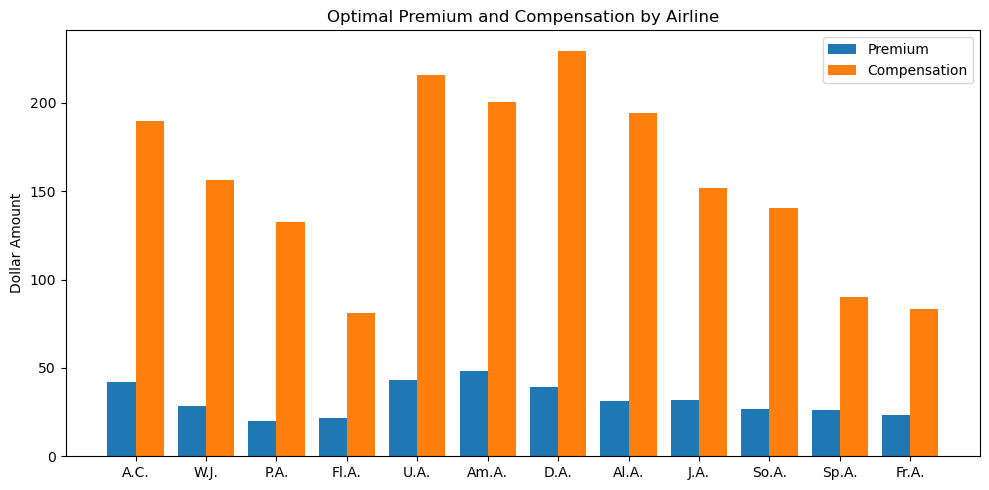

In [14]:
# Plot premium vs compensation
x_pos = np.arange(nA)

plt.figure(figsize=(10, 5))
plt.bar(x_pos - 0.2, premium_amount, width=0.4, label="Premium")
plt.bar(x_pos + 0.2, comp_amount, width=0.4, label="Compensation")

plt.xticks(x_pos, airlines_short)
plt.ylabel("Dollar Amount")
plt.title("Optimal Premium and Compensation by Airline")
plt.legend()
plt.tight_layout()
plt.show()

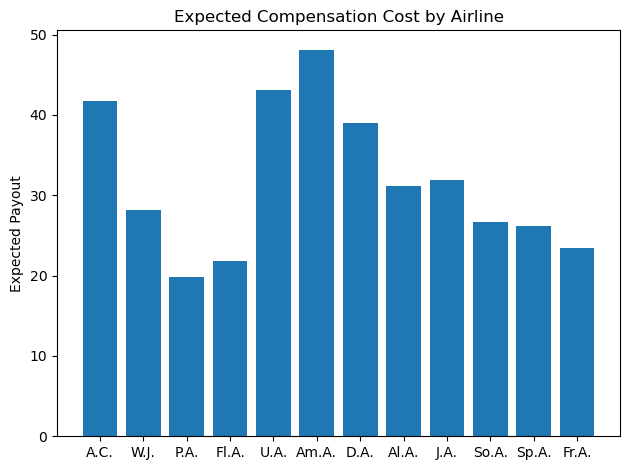

In [15]:
# Plot expected payout
plt.bar(airlines_short, expected_payout)

plt.ylabel("Expected Payout")
plt.title("Expected Compensation Cost by Airline")
plt.tight_layout()
plt.show()

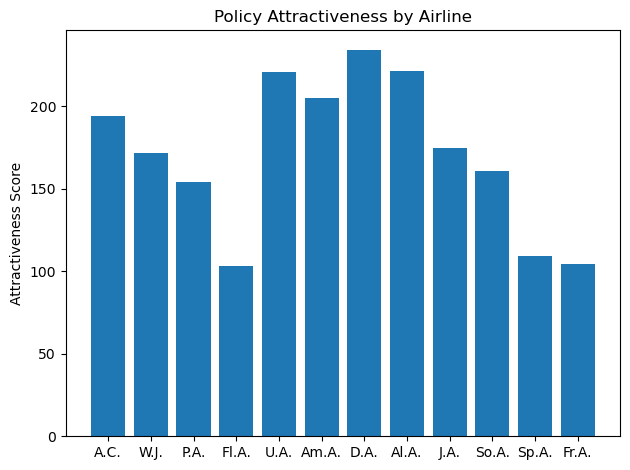

In [16]:
# Plot attractiveness
plt.bar(airlines_short, attractiveness)

plt.ylabel("Attractiveness Score")
plt.title("Policy Attractiveness by Airline")
plt.tight_layout()
plt.show()

## Discussion

The initial model reveals several structural properties:

- Airlines with lower delay probabilities (e.g. Porter, Alaska) receive higher compensation fractions because the risk penalty is smaller for them.
- High-risk budget carriers (Flair, Spirit, Frontier) are pushed towards the minimum attractiveness threshold – the fairness constraint is binding for these airlines
- The premium is driven to zero for many airlines because the original objective had no direct incentive to collect premiums.

### Constraint activity analysis

Before proceeding to the revised model, we check which constraints are actually binding at the optimum. constraints that are never active do not shape the solution and may safely be relaxed or removed.

Key questions:
1. Is the budget constraint (Constraint 1) active? If total expected payout $\sum q_i y_i T_i \ll B$, it is not binding.
2. Are the premium/compensation bounds (Constraints 2–3) active for any airline?
3. Is the diversification constraint (Constraint 6) binding?


These are checked numerically in the results cells above:
- Constraint 1 (budget cap) is not binding. The insurer's expected payout (381) falls well short of the budget (450), meaning the hard cap $B$ plays no role in determining the optimal solution. Tightening or loosening $B$ (within reason) would not change the result. The budget constraint is not a meaningful driver here and should not be emphasised
- Constraint 6 (diversification) is the binding structural constraint. The $\ell_2$-norm of the compensation vector hits its upper bound exactly ($\|y\|_2 = 2.000$). This constraint is what limits how large compensations can be overall, and it is the primary force compressing the solution. It deserves significant discussion
- Constraints 2–3 (premium/compensation bounds) are not active for any airline at the optimum, meaning the box bounds are loose and do not influence the allocation.
- Constraint 5 (attractiveness) should be checked airline-by-airline in the output table — airlines sitting exactly at $L_i = 20$ are being held there by this constraint rather than by the objective.

So the diversification constraint is doing all the work, the budget cap is doing nothing, which is interesting because the budget $B=450$ could be tightened substantially before it starts mattering

### Limitation: premiums collapse to zero

The original objective maximises attractiveness but treats collected premiums only negatively (via $-k_i x_i T_i$). Consequently the optimiser always sets $x_i$ as small as possible. The revised objective below corrects this by adding an explicit premium-revenue term.


## Revised Objective Function

To create a meaningful insurer-side tradeoff, we add an explicit premium revenue term and retain the expected-cost term:

$$
\max_{x,y} \quad \underbrace{\sum_{i \in A} (x_i T_i - q_i y_i T_i)}_{\text{net underwriting profit}}
+\alpha \underbrace{\sum_{i \in A} (-k_i x_i T_i + m_i y_i T_i)}_{\text{market attractiveness}}
- \lambda \underbrace{\sum_{i \in A} (\tilde{q}_i y_i T_i)^2}_{\text{risk regularisation}}
$$

where:
- Net underwriting profit incentivises the insurer to collect premiums and limit expected payouts
- Market attractiveness (weighted by $\alpha$) ensures policies remain competitive enough that customers actually buy them.
- Risk regularisation (weighted by $\lambda$) discourages over-exposure on high-risk airlines.

The tradeoff between $\alpha$ and $\lambda$ controls the solution behaviour:
- Large $\lambda$: penalises risk strongly -> lower compensations, more uniform across airlines
- Small $\lambda$: allows higher compensations -> more variation in expected payouts across airlines

A smaller $\lambda$ permits larger compensations, which creates more spread in expected payouts per airline, while a larger $\lambda$ compresses compensations towards uniformity.


In [17]:
# Revised objective weights
# alpha: weight on market attractiveness relative to net profit
# lam  : weight on quadratic risk regularisation#
# Valid range: alpha in [0.8, 1.2],  lam in [0.04, 0.06]
# Outside this range:
#   alpha > 1.2 -> attractiveness dominates, UW profit collapses to ~0
#   alpha < 0.8 -> insurer too conservative, policies less competitive
#   lam < 0.04  -> risk penalty too weak, premium almost equals payout (near-zero UW profit)
#   lam > 0.06  -> over-penalises risk, compensation collapses

# # Case 1: Balanced (lam=0.05 is midpoint of [0.04,0.06])
# alpha = 1.0
# lam   = 0.05

# # Case 2: Attractiveness-leaning (higher alpha)
# alpha = 1.2
# lam   = 0.04

# Case 3: Risk-focused (lower alpha)
alpha = 0.8
lam   = 0.06

In [18]:
# Revised objective function (insurer perspective)
objective_revised = cp.Maximize(
    cp.sum(cp.multiply(T, x) - cp.multiply(q * T, y)) +
    alpha * cp.sum(-cp.multiply(k * T, x) + cp.multiply(m * T, y)) -
    lam * cp.sum(cp.square(cp.multiply(q_tilde * T, y)))
)

In [19]:
problem_revised = cp.Problem(objective_revised, constraints)
problem_revised.solve()

print("Revised Status:", problem_revised.status)
print("Revised optimal objective value:", problem_revised.value)

Revised Status: optimal
Revised optimal objective value: 704.2881717528937


In [20]:
# Extract revised results
premium_amount_rev = x.value * T
comp_amount_rev = y.value * T
attractiveness_rev = -k * premium_amount_rev + m * comp_amount_rev
expected_payout_rev = q * comp_amount_rev
risk_penalty_component_rev = lam * q * (comp_amount_rev ** 2)

results_rev = pd.DataFrame({
    "Airport": airlines,
    "AverageFare": T,
    "DelayProb": q,
    "PremiumFraction_x": x.value,
    "CompFraction_y": y.value,
    "PremiumAmount": premium_amount_rev,
    "CompensationAmount": comp_amount_rev,
    "Attractiveness": attractiveness_rev,
    "ExpectedPayout": expected_payout_rev,
    "RiskPenaltyComponent": risk_penalty_component_rev
})

print("Revised optimal insurance design:")
results_rev.round(4)

Revised optimal insurance design:


,Airport,AverageFare,DelayProb,PremiumFraction_x,CompFraction_y,PremiumAmount,CompensationAmount,Attractiveness,ExpectedPayout,RiskPenaltyComponent
0,Air Canada,310,0.22,0.2,0.2432,62.0,75.3908,40.8690,16.5860,75.0258
1,WestJet,270,0.18,0.2,0.4622,54.0,124.7961,110.0951,22.4633,168.1998
2,Porter Airlines,240,0.15,0.2,0.8127,48.0,195.0471,210.3613,29.2571,342.3904
3,Flair Airlines,180,0.27,0.2,0.3795,36.0,68.3165,66.1065,18.4455,75.6078
4,United Airlines,330,0.20,0.2,0.2779,66.0,91.7160,56.7449,18.3432,100.9418
5,American Airlines,320,0.24,0.2,0.1969,64.0,63.0068,24.3883,15.1216,57.1659
6,Delta Air Lines,340,0.17,0.2,0.3764,68.0,127.9663,95.4812,21.7543,167.0287
7,Alaska Airlines,295,0.16,0.2,0.5641,59.0,166.4201,161.0978,26.6272,265.8783
8,JetBlue Airways,260,0.21,0.2,0.3741,52.0,97.2776,81.9247,20.4283,119.2329
9,Southwest Airlines,250,0.19,0.2,0.4732,50.0,118.2886,110.1409,22.4748,159.5109


In [21]:
# Revised summary metrics
total_premium_rev = np.sum(premium_amount_rev)
total_attractiveness_rev = np.sum(attractiveness_rev)
total_expected_payout_rev = np.sum(expected_payout_rev)
total_risk_penalty_rev = np.sum(risk_penalty_component_rev)

print("\nRevised Summary:")
print("Total premium collected:", total_premium_rev)
print("Total attractiveness:", total_attractiveness_rev)
print("Total expected payout:", total_expected_payout_rev)
print("Total risk penalty:", total_risk_penalty_rev)
print("net profit (premium - payout):", round(total_premium_rev - total_expected_payout_rev))


Revised Summary:
Total premium collected: 634.999999158814
Total attractiveness: 1052.8194610751268
Total expected payout: 244.98322112151303
Total risk penalty: 1649.3143139356575
net profit (premium - payout): 390


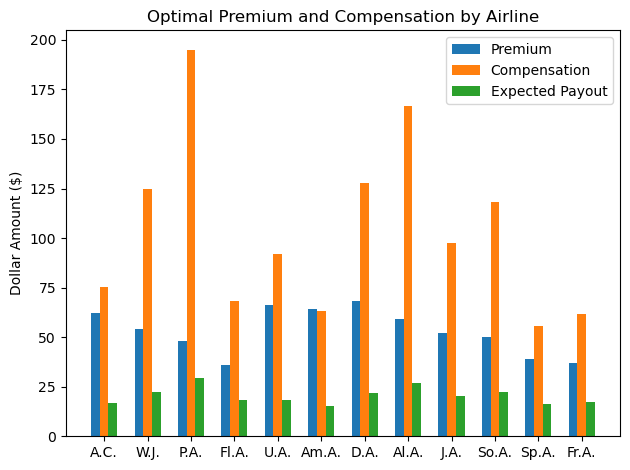

In [22]:
# revised premium vs compensation
x_pos = np.arange(nA)

plt.bar(x_pos - 0.2, premium_amount_rev, width=0.2, label="Premium")
plt.bar(x_pos , comp_amount_rev, width=0.2, label="Compensation")
plt.bar(x_pos + 0.2, expected_payout_rev, width=0.2, label="Expected Payout")

plt.xticks(x_pos, airlines_short)
plt.ylabel("Dollar Amount ($)")
plt.title("Optimal Premium and Compensation by Airline")
plt.legend()
plt.tight_layout()
plt.show()

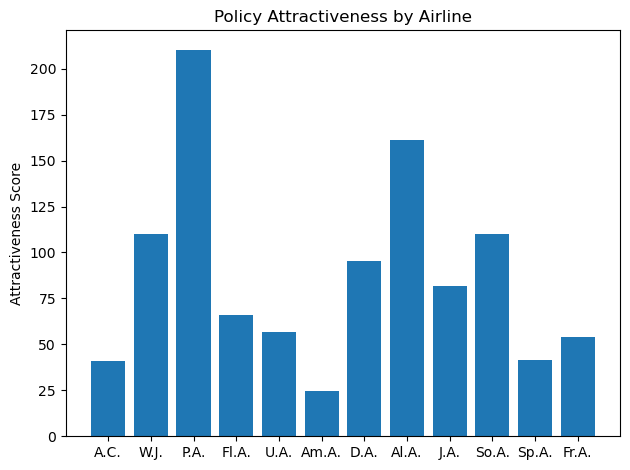

In [23]:
# attractiveness
plt.bar(airlines_short, attractiveness_rev)

plt.ylabel("Attractiveness Score")
plt.title("Policy Attractiveness by Airline")
plt.tight_layout()
plt.show()